# 03 — Full AIFS ENS v2 heat verification

This notebook aggregates all available monthly AIFS ENS v2 heat-hazard products and computes lead-dependent verification metrics over the full 2022–2025 period.

It includes all-case, observed-hot, and observed-nonhot temperature RMSE/MAE/bias; Brier scores for hot days and 2-/3-day event onset; regional stratification; spatial maps; reliability diagrams; and monthly variability diagnostics.

In [1]:
from __future__ import annotations
from pathlib import Path
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
xr.set_options(keep_attrs=True)

## Configuration

In [2]:
AIFS_MONTHLY_ROOT = Path("/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly")
ERA5_ROOT = Path("/net/monsoon/kylehall/ERA5/heat_extremes_climatology")
OUTPUT_ROOT = Path("/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/full_verification")
SCORE_DIR = OUTPUT_ROOT / "scores"
FIGURE_DIR = OUTPUT_ROOT / "figures"
MAP_DIR = FIGURE_DIR / "maps"
RELIABILITY_DIR = FIGURE_DIR / "reliability"
for d in (SCORE_DIR, FIGURE_DIR, MAP_DIR, RELIABILITY_DIR): d.mkdir(parents=True, exist_ok=True)
ERA5_DAILY_STORE = ERA5_ROOT / "daily" / "t2m_daily_mean.zarr"
ERA5_HAZARD_STORE = ERA5_ROOT / "hazards" / "t2m_daily_mean_q95_hazards.zarr"
MAP_FORECAST_DAYS = (0,5,10,13)
RELIABILITY_FORECAST_DAYS = (0,5,10,13)
RELIABILITY_BIN_EDGES = np.linspace(0,1,11)
REGIONS = {
    "global": {},
    "tropics": {"latitude": slice(-23.5,23.5)},
    "nh_extratropics": {"latitude": slice(23.5,90)},
    "sh_extratropics": {"latitude": slice(-90,-23.5)},
    "conus": {"latitude": slice(24,50), "longitude": slice(235,294)},
    "europe": {"latitude": slice(35,72), "longitude": slice(350,40)},
    "east_asia": {"latitude": slice(20,55), "longitude": slice(100,150)},
}
print(OUTPUT_ROOT)

/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/full_verification


## Utilities

In [8]:
def normalize_longitude_like(source, target_longitude):
    use360 = float(target_longitude.min()) >= 0 and float(target_longitude.max()) > 180
    lon = source.longitude % 360 if use360 else ((source.longitude + 180) % 360) - 180
    return source.assign_coords(longitude=lon).sortby("longitude")

def map_to_forecast_grid(source, forecast, method):
    source = normalize_longitude_like(source, forecast.longitude)
    if np.array_equal(source.latitude.values, forecast.latitude.values) and np.array_equal(source.longitude.values, forecast.longitude.values):
        return source
    return source.interp(latitude=forecast.latitude, longitude=forecast.longitude, method=method)

def match_era5_by_valid_date(observation, valid_date):
    observation = observation.rename({"time":"era5_time"})
    valid_date = valid_date.rename({"time":"initialization"})
    matched = observation.sel(era5_time=valid_date, longitude=valid_date.longitude)
    return matched.rename({"initialization":"time"}).transpose("time","forecast_day","latitude","longitude")

def latitude_weights(da):
    return np.cos(np.deg2rad(da.latitude))

def weighted_case_mean(field, condition=None, reduce_dims=("time","latitude","longitude")):
    if condition is not None: field = field.where(condition)
    w = latitude_weights(field).broadcast_like(field)
    valid = field.notnull()
    return (field.fillna(0)*w).sum(reduce_dims) / w.where(valid).sum(reduce_dims)

def effective_weighted_case_count(condition):
    w = latitude_weights(condition).broadcast_like(condition)
    return w.where(condition).sum(("time","latitude","longitude"))

def select_region(da, region):
    out = da
    if "latitude" in region:
        s = region["latitude"]
        if out.latitude.values[0] > out.latitude.values[-1]: s = slice(s.stop,s.start)
        out = out.sel(latitude=s)
    if "longitude" in region:
        s = region["longitude"]
        if s.start <= s.stop:
            out = out.sel(longitude=s)
        else:
            out = xr.concat([out.sel(longitude=slice(s.start,None)), out.sel(longitude=slice(None,s.stop))], dim="longitude").sortby("longitude")
    return out

def plot_lead_curves(frame, columns, ylabel, title, output_path):
    fig, ax = plt.subplots(figsize=(8,4.8))
    for col,label in columns.items(): ax.plot(frame.forecast_day, frame[col], marker="o", label=label)
    ax.set(xlabel="Forecast day", ylabel=ylabel, title=title); ax.grid(alpha=.3); ax.legend()
    fig.savefig(output_path,dpi=180,bbox_inches="tight"); plt.show()

def plot_global_map(field,title,cbar_label,output_path,vmin=None,vmax=None):
    fig=plt.figure(figsize=(12,4.8)); ax=plt.axes(projection=ccrs.PlateCarree())
    field.plot(ax=ax,transform=ccrs.PlateCarree(),vmin=vmin,vmax=vmax,cbar_kwargs={"label":cbar_label})
    ax.coastlines(); ax.set_title(title); fig.savefig(output_path,dpi=180,bbox_inches="tight"); plt.show()

def weighted_scalar_mean(
    field: xr.DataArray,
    condition: xr.DataArray | None = None,
) -> xr.DataArray:
    if condition is not None:
        field = field.where(condition)

    weights = np.cos(np.deg2rad(field["latitude"]))

    numerator = (
        field.fillna(0) * weights
    ).sum(("time", "latitude", "longitude"))

    denominator = (
        field.notnull() * weights
    ).sum(("time", "latitude", "longitude"))

    return numerator / denominator

## 1. Open all monthly forecast stores

In [4]:
monthly_stores = sorted(AIFS_MONTHLY_ROOT.glob("20??/aifs_ens_v2_heat_20????.zarr"))
print("Monthly stores found:", len(monthly_stores))
if not monthly_stores: raise FileNotFoundError(AIFS_MONTHLY_ROOT)
aifs = xr.open_mfdataset(
    [str(p) for p in monthly_stores], engine="zarr", combine="nested", concat_dim="time",
    chunks={"time":1,"forecast_day":8,"latitude":180,"longitude":180}, parallel=True,
    data_vars="minimal", coords="minimal", compat="override", join="override",
    combine_attrs="override", consolidated=False,
).sortby("time")

jjas = aifs.time.dt.month.isin([6, 7, 8, 9])
aifs = aifs.sel(time=jjas)

print(aifs)
print(aifs.time.values[0], aifs.time.values[-1])

Monthly stores found: 48
<xarray.Dataset> Size: 28GB
Dimensions:                            (time: 120, forecast_day: 14,
                                        latitude: 721, longitude: 1440)
Coordinates:
  * time                               (time) datetime64[ns] 960B 2022-06-01 ...
  * forecast_day                       (forecast_day) int16 28B 0 1 2 ... 12 13
  * latitude                           (latitude) float64 6kB 90.0 ... -90.0
  * longitude                          (longitude) float64 12kB 0.0 ... 359.8
    local_solar_offset_hours           (longitude) float64 12kB dask.array<chunksize=(180,), meta=np.ndarray>
    dayofyear                          (time, forecast_day, longitude) int64 19MB dask.array<chunksize=(1, 8, 180), meta=np.ndarray>
    valid_date                         (time, forecast_day, longitude) datetime64[ns] 19MB dask.array<chunksize=(1, 8, 180), meta=np.ndarray>
Data variables:
    heatwave_start_q95_3d_probability  (time, forecast_day, latitude, longit

## 2. Match ERA5 observations

In [5]:
forecast_temperature = aifs.t2m_daily_mean_ensemble_mean
hot_probability = aifs.hot_day_q95_probability
event_2d_probability = aifs.heatwave_start_q95_2d_probability
event_3d_probability = aifs.heatwave_start_q95_3d_probability
era5_temperature = xr.open_zarr(ERA5_DAILY_STORE, consolidated=True, chunks={})["t2m_daily_mean"]
era5_hazards = xr.open_zarr(ERA5_HAZARD_STORE, consolidated=True, chunks={})
era5_temperature = map_to_forecast_grid(era5_temperature, forecast_temperature, "linear")
era5_hot = map_to_forecast_grid(era5_hazards.hot_day_q95.astype(np.float32), hot_probability, "nearest") > .5
era5_event_2d = map_to_forecast_grid(era5_hazards.heatwave_start_q95_2d.astype(np.float32), event_2d_probability, "nearest") > .5
era5_event_3d = map_to_forecast_grid(era5_hazards.heatwave_start_q95_3d.astype(np.float32), event_3d_probability, "nearest") > .5
matched_temperature = match_era5_by_valid_date(era5_temperature, aifs.valid_date)
matched_hot = match_era5_by_valid_date(era5_hot, aifs.valid_date)
matched_event_2d = match_era5_by_valid_date(era5_event_2d, aifs.valid_date)
matched_event_3d = match_era5_by_valid_date(era5_event_3d, aifs.valid_date)
xr.align(forecast_temperature, matched_temperature, hot_probability, matched_hot, join="exact")
print("Forecast and ERA5 align exactly")

Forecast and ERA5 align exactly


## 3. Global temperature metrics

In [ ]:


rows = []

for forecast_day in forecast_temperature["forecast_day"].values:
    print(f"Forecast day {forecast_day}", flush=True)

    forecast = forecast_temperature.sel(
        forecast_day=forecast_day
    )

    observed = matched_temperature.sel(
        forecast_day=forecast_day
    )

    hot = matched_hot.sel(
        forecast_day=forecast_day
    ).astype(bool)

    error = forecast - observed
    squared_error = error**2
    absolute_error = abs(error)

    metrics = xr.Dataset(
        {
            "rmse_all": np.sqrt(
                weighted_scalar_mean(squared_error)
            ),
            "rmse_hot": np.sqrt(
                weighted_scalar_mean(squared_error, hot)
            ),
            "rmse_nonhot": np.sqrt(
                weighted_scalar_mean(squared_error, ~hot)
            ),
            "mae_all": weighted_scalar_mean(
                absolute_error
            ),
            "mae_hot": weighted_scalar_mean(
                absolute_error, hot
            ),
            "mae_nonhot": weighted_scalar_mean(
                absolute_error, ~hot
            ),
            "bias_all": weighted_scalar_mean(
                error
            ),
            "bias_hot": weighted_scalar_mean(
                error, hot
            ),
            "bias_nonhot": weighted_scalar_mean(
                error, ~hot
            ),
            "hot_case_support": (
                hot
                * np.cos(np.deg2rad(hot["latitude"]))
            ).sum(("time", "latitude", "longitude")),
            "nonhot_case_support": (
                (~hot)
                * np.cos(np.deg2rad(hot["latitude"]))
            ).sum(("time", "latitude", "longitude")),
        }
    )

    with ProgressBar():
        metrics = metrics.compute()

    row = {
        "forecast_day": int(forecast_day),
        **{
            name: float(metrics[name])
            for name in metrics.data_vars
        },
    }
    rows.append(row)

    # Save progress after every lead.
    pd.DataFrame(rows).to_csv(
        SCORE_DIR / "global_temperature_metrics_by_lead.csv",
        index=False,
    )

global_temperature_df = pd.DataFrame(rows)
display(global_temperature_df)

Forecast day 0
[########################################] | 100% Completed | 413.37 s
Forecast day 1
[########################################] | 100% Completed | 373.06 s
Forecast day 2
[########################################] | 100% Completed | 375.04 s
Forecast day 3
[########################################] | 100% Completed | 374.96 s
Forecast day 4
[########################################] | 100% Completed | 361.33 s
Forecast day 5
[########################################] | 100% Completed | 363.99 s
Forecast day 6
[########################################] | 100% Completed | 362.10 s
Forecast day 7
[########################################] | 100% Completed | 362.25 s
Forecast day 8
[########################################] | 100% Completed | 371.42 s
Forecast day 9
[########################################] | 100% Completed | 371.79 s
Forecast day 10
[########################################] | 100% Completed | 375.94 s
Forecast day 11
[####################################

,forecast_day,rmse_all,rmse_hot,rmse_nonhot,mae_all,mae_hot,mae_nonhot,bias_all,bias_hot,bias_nonhot,hot_case_support,nonhot_case_support
0,0,0.511931,0.496276,0.514159,0.308280,0.291391,0.310727,-0.022863,-0.106911,-0.010688,1.002165e+07,6.918391e+07
1,1,0.637807,0.581935,0.645591,0.392860,0.362163,0.397360,-0.014163,-0.154355,0.006388,1.012654e+07,6.907902e+07
2,2,0.748305,0.669437,0.759110,0.460618,0.417731,0.466866,-0.005566,-0.204143,0.023361,1.007100e+07,6.913456e+07
3,3,0.883724,0.803181,0.894903,0.536796,0.485703,0.544273,0.001886,-0.273163,0.042137,1.011135e+07,6.909421e+07
4,4,1.042432,1.001589,1.048227,0.624105,0.576586,0.631001,0.001552,-0.377663,0.056582,1.003735e+07,6.916821e+07
5,5,1.217265,1.216740,1.217341,0.720424,0.684593,0.725657,0.003586,-0.501435,0.077332,1.009219e+07,6.911337e+07
6,6,1.388547,1.476647,1.375197,0.817714,0.816147,0.817944,0.009182,-0.649547,0.105464,1.010066e+07,6.910490e+07
7,7,1.552286,1.723648,1.525319,0.912491,0.962185,0.905144,0.004097,-0.819356,0.125835,1.020147e+07,6.900409e+07
8,8,1.677315,1.950689,1.633205,0.993514,1.102481,0.977471,0.007216,-0.979697,0.152523,1.016504e+07,6.904052e+07
9,9,1.781944,2.173439,1.716411,1.064837,1.248007,1.037718,0.011310,-1.141958,0.182051,1.021417e+07,6.899139e+07


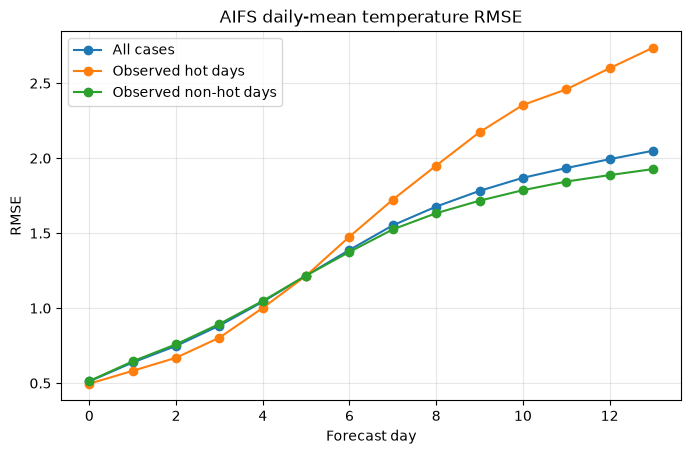

In [10]:
plot_lead_curves(global_temperature_df, {"rmse_all":"All cases","rmse_hot":"Observed hot days","rmse_nonhot":"Observed non-hot days"}, "RMSE", "AIFS daily-mean temperature RMSE", FIGURE_DIR/"global_rmse_by_lead.png")

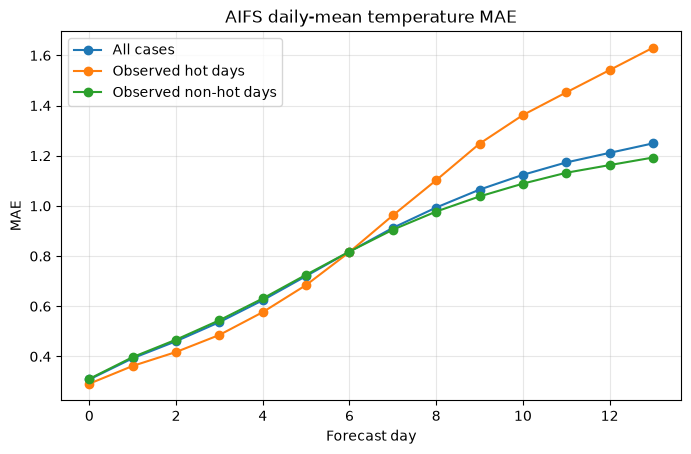

In [11]:
plot_lead_curves(global_temperature_df, {"mae_all":"All cases","mae_hot":"Observed hot days","mae_nonhot":"Observed non-hot days"}, "MAE", "AIFS daily-mean temperature MAE", FIGURE_DIR/"global_mae_by_lead.png")

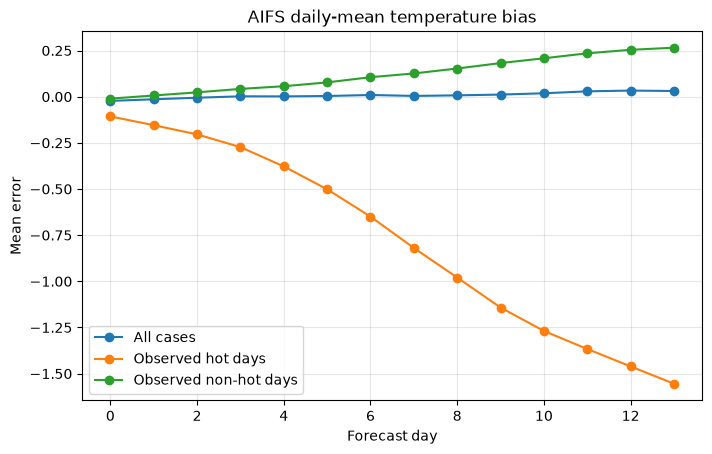

In [12]:
plot_lead_curves(global_temperature_df, {"bias_all":"All cases","bias_hot":"Observed hot days","bias_nonhot":"Observed non-hot days"}, "Mean error", "AIFS daily-mean temperature bias", FIGURE_DIR/"global_bias_by_lead.png")

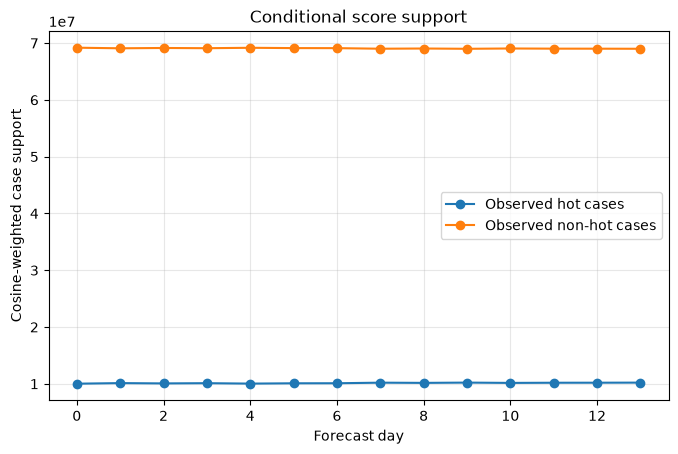

In [13]:
plot_lead_curves(global_temperature_df,{"hot_case_support":"Observed hot cases","nonhot_case_support":"Observed non-hot cases"},"Cosine-weighted case support","Conditional score support",FIGURE_DIR/"global_case_support_by_lead.png")

## 4. Global probabilistic metrics

In [ ]:
rows = []

event_defs = {
    "hot_day_q95": (
        hot_probability,
        matched_hot,
    ),
    "heatwave_start_q95_2d": (
        event_2d_probability,
        matched_event_2d,
    ),
    "heatwave_start_q95_3d": (
        event_3d_probability,
        matched_event_3d,
    ),
}

for lead in hot_probability.forecast_day.values:

    print(f"Lead {lead}", flush=True)

    row = {"forecast_day": int(lead)}

    for name, (p, y) in event_defs.items():

        p = p.sel(forecast_day=lead)
        y = y.sel(forecast_day=lead).astype(np.float32)

        with ProgressBar():
            brier = weighted_scalar_mean(
                (p - y) ** 2
            ).compute()

            mean_probability = weighted_scalar_mean(
                p
            ).compute()

            observed_frequency = weighted_scalar_mean(
                y
            ).compute()

        row[f"{name}_brier_score"] = float(brier)
        row[f"{name}_mean_probability"] = float(mean_probability)
        row[f"{name}_observed_frequency"] = float(observed_frequency)
        row[f"{name}_frequency_bias"] = (
            float(mean_probability) - float(observed_frequency)
        )

    rows.append(row)

    # checkpoint after every lead
    pd.DataFrame(rows).to_csv(
        SCORE_DIR / "global_probability_metrics_by_lead.csv",
        index=False,
    )

global_probability_df = pd.DataFrame(rows)
display(global_probability_df)

Lead 0
[########################################] | 100% Completed | 102.61 ms
[########################################] | 100% Completed | 3.85 sms
[########################################] | 100% Completed | 98.28 s
[########################################] | 100% Completed | 39.68 s
[########################################] | 100% Completed | 18.91 s
[########################################] | 100% Completed | 101.89 ms
[########################################] | 100% Completed | 101.81 ms
[########################################] | 100% Completed | 83.13 s
[########################################] | 100% Completed | 35.97 s
[########################################] | 100% Completed | 18.20 s
[########################################] | 100% Completed | 101.52 ms
[########################################] | 100% Completed | 102.17 ms
[########################################] | 100% Completed | 80.64 s
[########################################] | 100% Completed | 32.92 s
[#

In [ ]:
plot_lead_curves(global_probability_df,{"hot_day_q95_brier_score":"Hot day","heatwave_start_q95_2d_brier_score":"2+ day onset","heatwave_start_q95_3d_brier_score":"3+ day onset"},"Brier score","AIFS heat-hazard Brier score",FIGURE_DIR/"global_brier_by_lead.png")

In [ ]:
plot_lead_curves(global_probability_df,{"hot_day_q95_mean_probability":"Forecast probability","hot_day_q95_observed_frequency":"Observed frequency"},"Area-weighted frequency","Hot-day forecast probability versus observed frequency",FIGURE_DIR/"global_hot_day_frequency_by_lead.png")

## 5. Regional stratification

In [ ]:
regional=[]
for name,region in REGIONS.items():
    print(name)
    e=select_region(error,region); h=select_region(hot,region); nh=~h
    p=select_region(hot_probability,region); y=select_region(matched_hot.astype(np.float32),region)
    ds=xr.Dataset({
        "rmse_all":np.sqrt(weighted_case_mean(e**2)),
        "rmse_hot":np.sqrt(weighted_case_mean(e**2,h)),
        "rmse_nonhot":np.sqrt(weighted_case_mean(e**2,nh)),
        "bias_all":weighted_case_mean(e),
        "bias_hot":weighted_case_mean(e,h),
        "bias_nonhot":weighted_case_mean(e,nh),
        "hot_day_brier_score":weighted_case_mean((p-y)**2),
        "mean_hot_day_probability":weighted_case_mean(p),
        "observed_hot_day_frequency":weighted_case_mean(y),
        "hot_case_support":effective_weighted_case_count(h),
    }).compute()
    f=ds.to_dataframe().reset_index(); f["region"]=name; regional.append(f)
regional_scores=pd.concat(regional,ignore_index=True)
regional_scores.to_csv(SCORE_DIR/"regional_metrics_by_lead.csv",index=False)
display(regional_scores.head())

In [ ]:
fig,ax=plt.subplots(figsize=(9,5.5))
for name in REGIONS:
    s=regional_scores[regional_scores.region==name]; ax.plot(s.forecast_day,s.rmse_hot,marker="o",label=name)
ax.set(xlabel="Forecast day",ylabel="Observed-hot-day RMSE",title="AIFS hot-day temperature RMSE by region"); ax.grid(alpha=.3); ax.legend(ncol=2)
fig.savefig(FIGURE_DIR/"regional_hot_day_rmse_by_lead.png",dpi=180,bbox_inches="tight"); plt.show()

In [ ]:
fig,ax=plt.subplots(figsize=(9,5.5))
for name in REGIONS:
    s=regional_scores[regional_scores.region==name]; ax.plot(s.forecast_day,s.hot_day_brier_score,marker="o",label=name)
ax.set(xlabel="Forecast day",ylabel="Brier score",title="AIFS hot-day Brier score by region"); ax.grid(alpha=.3); ax.legend(ncol=2)
fig.savefig(FIGURE_DIR/"regional_hot_day_brier_by_lead.png",dpi=180,bbox_inches="tight"); plt.show()

## 6. Spatial maps

In [ ]:
for day in MAP_FORECAST_DAYS:
    e=error.sel(forecast_day=day); p=hot_probability.sel(forecast_day=day); y=matched_hot.sel(forecast_day=day).astype(np.float32)
    plot_global_map(e.mean("time").compute(),f"Temperature bias — forecast day {day}","Mean forecast error",MAP_DIR/f"temperature_bias_day{day}.png")
    plot_global_map(((p-y)**2).mean("time").compute(),f"Hot-day Brier score — forecast day {day}","Brier score",MAP_DIR/f"hot_day_brier_day{day}.png",vmin=0)
    plot_global_map((p.mean("time")-y.mean("time")).compute(),f"Forecast probability minus observed frequency — forecast day {day}","Probability-frequency bias",MAP_DIR/f"hot_day_frequency_bias_day{day}.png")

## 7. Reliability diagrams

In [ ]:
def reliability_table(probability, observed, bin_edges):
    probability=probability.compute(); observed=observed.astype(np.float32).compute(); w=latitude_weights(probability).broadcast_like(probability)
    p=probability.values.ravel(); y=observed.values.ravel(); ww=w.values.ravel(); valid=np.isfinite(p)&np.isfinite(y)&np.isfinite(ww)
    p,y,ww=p[valid],y[valid],ww[valid]
    b=np.clip(np.digitize(p,bin_edges)-1,0,len(bin_edges)-2)
    rows=[]
    for i in range(len(bin_edges)-1):
        s=b==i
        if not np.any(s): rows.append({"bin_lower":bin_edges[i],"bin_upper":bin_edges[i+1],"weighted_count":0.,"mean_probability":np.nan,"observed_frequency":np.nan}); continue
        rows.append({"bin_lower":bin_edges[i],"bin_upper":bin_edges[i+1],"weighted_count":ww[s].sum(),"mean_probability":np.average(p[s],weights=ww[s]),"observed_frequency":np.average(y[s],weights=ww[s])})
    return pd.DataFrame(rows)

In [ ]:
frames=[]
for day in RELIABILITY_FORECAST_DAYS:
    t=reliability_table(hot_probability.sel(forecast_day=day),matched_hot.sel(forecast_day=day),RELIABILITY_BIN_EDGES); t["forecast_day"]=day; frames.append(t)
    fig,ax=plt.subplots(figsize=(5.5,5.5)); ax.plot([0,1],[0,1],"--",label="Perfect reliability"); ax.plot(t.mean_probability,t.observed_frequency,marker="o",label=f"Forecast day {day}")
    ax.set(xlabel="Mean forecast probability",ylabel="Observed event frequency",title="Hot-day reliability",xlim=(0,1),ylim=(0,1)); ax.grid(alpha=.3); ax.legend()
    fig.savefig(RELIABILITY_DIR/f"hot_day_reliability_day{day}.png",dpi=180,bbox_inches="tight"); plt.show()
reliability_scores=pd.concat(frames,ignore_index=True); reliability_scores.to_csv(SCORE_DIR/"hot_day_reliability.csv",index=False)

## 8. Monthly variability and skill translation

In [ ]:
rows=[]
for year in range(2022,2026):
    for month in range(1,13):
        sel=(aifs.time.dt.year==year)&(aifs.time.dt.month==month)
        if int(sel.sum())==0: continue
        e=error.sel(time=sel); h=hot.sel(time=sel); p=hot_probability.sel(time=sel); y=matched_hot.sel(time=sel).astype(np.float32)
        ds=xr.Dataset({"rmse_all":np.sqrt(weighted_case_mean(e**2)),"rmse_hot":np.sqrt(weighted_case_mean(e**2,h)),"bias_hot":weighted_case_mean(e,h),"hot_day_brier_score":weighted_case_mean((p-y)**2)}).compute()
        f=ds.to_dataframe().reset_index(); f["year"]=year; f["month"]=month; rows.append(f)
monthly_scores=pd.concat(rows,ignore_index=True); monthly_scores.to_csv(SCORE_DIR/"monthly_metrics_by_lead.csv",index=False); display(monthly_scores.head())

In [ ]:
for day in (0,5,10,13):
    s=monthly_scores[monthly_scores.forecast_day==day]
    fig,ax=plt.subplots(figsize=(8,4.8)); ax.scatter(s.rmse_all,s.hot_day_brier_score)
    ax.set(xlabel="Monthly all-case RMSE",ylabel="Monthly hot-day Brier score",title=f"Deterministic versus hazard skill — forecast day {day}"); ax.grid(alpha=.3)
    fig.savefig(FIGURE_DIR/f"monthly_rmse_vs_brier_day{day}.png",dpi=180,bbox_inches="tight"); plt.show()

## Interpretation checklist

- All-case RMSE, MAE, and Brier score should generally worsen with lead.
- Hot-day RMSE must be interpreted alongside hot-day bias and support.
- Reliability and probability-frequency bias should tell a consistent story.
- Regional curves should not be dominated by tiny event samples.
- Monthly RMSE-versus-Brier scatter plots directly test whether deterministic skill translates into hazard skill.